In [1]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Set a nice visual theme
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (12, 6)

# Define your directory
RESULTS_DIR = "../results/dev"


In [2]:
def load_metrics(directory):
    data = []
    path = Path(directory)
    
    # Iterate over all json files
    for file_path in path.glob("*.json"):
        try:
            with open(file_path, 'r') as f:
                metrics = json.load(f)
            
            # Parse filename: "model-name_prompt_1.json"
            filename = file_path.stem # removes .json
            
            # reliable split based on the standard naming convention
            if "_prompt_" in filename:
                model_name, prompt_part = filename.split("_prompt_")
                prompt_id = prompt_part
            else:
                # Fallback if naming convention breaks
                model_name = filename
                prompt_id = "unknown"

            # Add metadata to the metrics dictionary
            metrics['model'] = model_name
            metrics['prompt_id'] = prompt_id
            metrics['filename'] = filename
            
            data.append(metrics)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    # Create DataFrame
    df = pd.DataFrame(data)
    
    # Convert prompt_id to numeric if possible for better sorting, else keep string
    try:
        df['prompt_id'] = pd.to_numeric(df['prompt_id'])
    except:
        pass
        
    return df

# Load the data
df = load_metrics(RESULTS_DIR)

# Sort by Overall Score (descending)
df = df.sort_values(by="overall_score", ascending=False).reset_index(drop=True)

# Display the top 5 rows
print(f"Loaded {len(df)} result files.")
display(df.head())

Loaded 223 result files.


,rouge1,rouge2,rougeL,rougeLsum,bertscore,medcon,alignscore,overall_score,model,prompt_id,filename
0,97.966540,96.160920,97.276885,97.276885,97.848322,90.000000,97.571760,95.674242,anthropic-claude-sonnet-4-5,10,anthropic-claude-sonnet-4-5_prompt_10
1,97.807810,95.845130,97.807810,97.807810,97.402954,88.333333,95.691810,94.808977,x-ai-grok-4-1-fast,10,x-ai-grok-4-1-fast_prompt_10
2,97.891109,95.416092,97.520738,97.520738,97.730896,88.333333,95.342867,94.731959,openai-gpt-5-2,8,openai-gpt-5-2_prompt_8
3,97.240814,95.431034,96.595653,96.595653,97.817171,90.000000,94.331091,94.685979,anthropic-claude-sonnet-4-5,8,anthropic-claude-sonnet-4-5_prompt_8
4,98.203609,96.160920,98.203609,98.203609,96.712869,87.333333,96.290975,94.635196,openai-gpt-5-2,10,openai-gpt-5-2_prompt_10


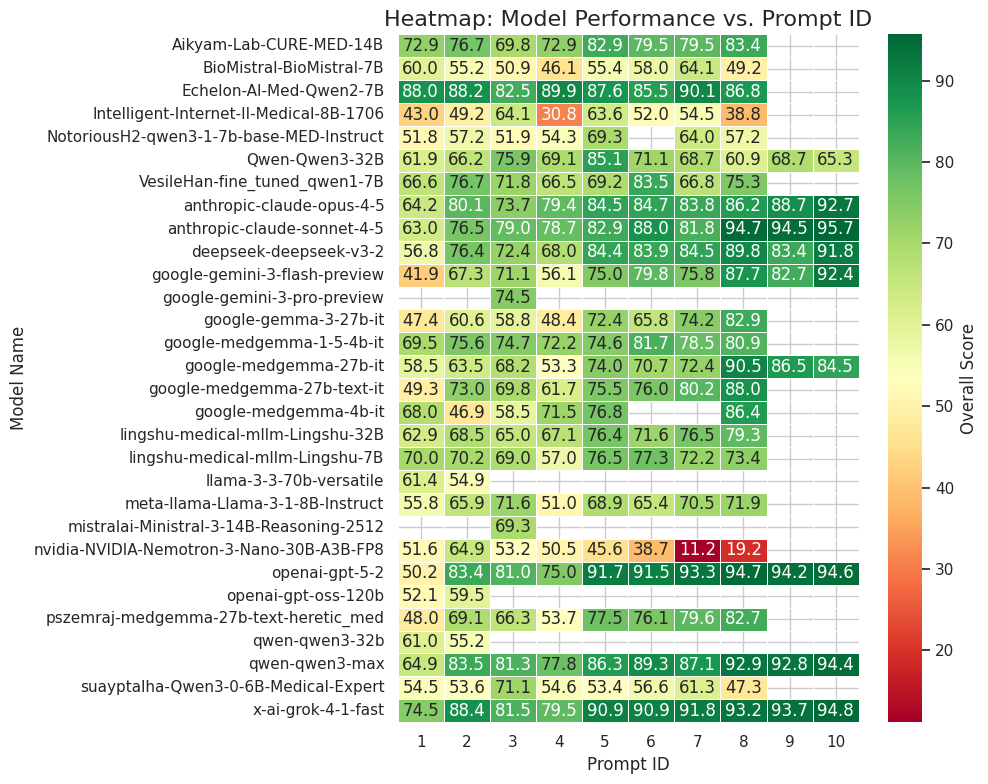

In [3]:
# Create a pivot table: Rows=Model, Cols=Prompt ID, Values=Overall Score
pivot_df = df.pivot_table(index="model", columns="prompt_id", values="overall_score")

plt.figure(figsize=(10, 8))
sns.heatmap(
    pivot_df, 
    annot=True, 
    fmt=".1f", 
    cmap="RdYlGn", # Red to Green colormap
    linewidths=.5,
    cbar_kws={'label': 'Overall Score'}
)

plt.title("Heatmap: Model Performance vs. Prompt ID", fontsize=16)
plt.ylabel("Model Name")
plt.xlabel("Prompt ID")
plt.tight_layout()
plt.show()

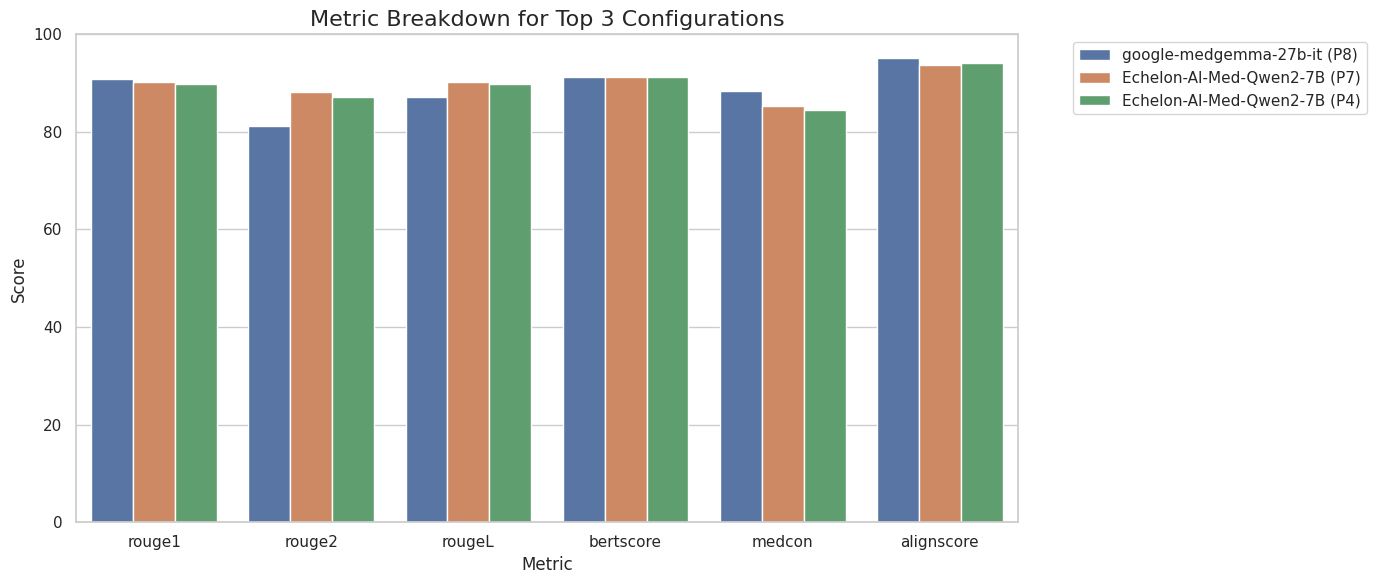

In [29]:
# Melt the dataframe to make it suitable for a grouped bar chart
top_3_configs = df.head(3)['filename'].tolist()
subset = df[df['filename'].isin(top_3_configs)]

# Select only numeric metric columns (excluding overall_score to avoid skewing scale)
metric_cols = ['rouge1', 'rouge2', 'rougeL', 'bertscore', 'medcon', 'alignscore']
melted = subset.melt(id_vars=['model', 'prompt_id'], value_vars=metric_cols, var_name='Metric', value_name='Score')

# Create label for legend
melted['Configuration'] = melted['model'] + " (P" + melted['prompt_id'].astype(str) + ")"

plt.figure(figsize=(14, 6))
sns.barplot(
    data=melted,
    x="Metric",
    y="Score",
    hue="Configuration",
    palette="deep"
)

plt.title("Metric Breakdown for Top 3 Configurations", fontsize=16)
plt.ylim(0, 100)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()